# Лабораторная работа №2

**Тема:** Программно- алгоритмическая реализация методов Рунге-Кутта 2-го и 4-го порядков точности при решении системы ОДУ.

**Цель работы:** Получение навыков разработки алгоритмов решения задачи Коши при реализации моделей, построенных на системе ОДУ, с использованием метода Рунге-Кутта
2-го и 4-го порядков точности.

**Исходные данные:**
1. Дано дифференциальное уравнение второго порядка с соответствующими краевыми
условиями, описывающее радиационный перенос в цилиндре, заполненном излучающим
высокотемпературным газом

![img:form](./images/form.png)

![img:table](./images/table.png)

**Замечания:**

1. При сведении исходного уравнения к системе уравнений 1-го порядка замену
переменных выполнить по формуле

![img:table](./images/form2.png)

В этом случае новая переменная F будет иметь физический смысл потока излучения (Вт/ см2).

2. При интерполяции по таблице1 целесообразно сделать замену переменных,
позволяющую выполнять данную процедуру полиномом 1-й степени

![img:table](./images/zam2.png)


In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt


def create_k_interpolator(T_data, k_data):
    if any(T_data[i] >= T_data[i + 1] for i in range(len(T_data) - 1)):
        raise ValueError("Массив T_data должен быть возрастающим.")

    lnT = [math.log(T) for T in T_data]
    lnK = [math.log(k) for k in k_data]

    def k_of_T(T):
        x = math.log(T)

        if T < T_data[0]:
            x0, x1 = lnT[0], lnT[1]
            y0, y1 = lnK[0], lnK[1]
            y = y0 + (y1 - y0) * ((x - x0) / (x1 - x0))
            return math.exp(y)

        if T > T_data[-1]:
            x0, x1 = lnT[-2], lnT[-1]
            y0, y1 = lnK[-2], lnK[-1]
            y = y0 + (y1 - y0) * ((x - x0) / (x1 - x0))
            return math.exp(y)

        for i in range(len(lnT) - 1):
            if x >= lnT[i] and x <= lnT[i + 1]:
                y0, y1 = lnK[i], lnK[i + 1]
                x0, x1 = lnT[i], lnT[i + 1]
                y = y0 + (y1 - y0) * ((x - x0) / (x1 - x0))
                return math.exp(y)

        return None

    return k_of_T


def T_of_r(r):
    return T0 + (Tw - T0) * ((r / R) ** p_exp)


def U_p_of_r(r):
    T_val = T_of_r(r)
    return A_p / (math.exp(B_p / T_val) - 1.0)


def derivatives(r, y):
    U, F = y
    k_val = k_of_r(r)
    Up = U_p_of_r(r)
   
    if abs(r) < 1.0e-14:
        return [
            -3.0 * k_val / c_light * F,
            - c_light * k_val * (U - Up)
        ]
    else:
        return [
            -3.0 * k_val / c_light * F,
            - c_light * k_val * (U - Up) - F / r
        ]


def rk2_step(f, r, y, h):
    k1 = f(r, y) 
    y_mid = y + 0.5 * h * np.array(k1) 
    k2 = f(r + 0.5 * h, y_mid)
    y_new = y + h * np.array(k2)
    return y_new


def rk4_step(f, r, y, h):
    k1 = np.array(f(r, y))
    k2 = np.array(f(r + 0.5 * h, y + 0.5 * h * k1))
    k3 = np.array(f(r + 0.5 * h, y + 0.5 * h * k2))
    k4 = np.array(f(r + h, y + h * k3))
    y_new = y + (h / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)
    return y_new


def solve_ivp_shooting(phi, method='rk4', Nsteps=2000):
    U0 = phi * U_p_of_r(0.0)
    F0 = 0.0
    y = np.array([U0, F0], dtype=float)

    r_vals = np.linspace(0, R, Nsteps + 1)
    U_vals = np.zeros(Nsteps + 1)
    F_vals = np.zeros(Nsteps + 1)
    U_vals[0] = U0
    F_vals[0] = F0

    h = (R - 0.0) / Nsteps

    step_func = rk4_step if (method == 'rk4') else rk2_step

    for i in range(Nsteps):
        r_i = r_vals[i]
        y = step_func(derivatives, r_i, y, h)
        U_vals[i + 1] = y[0]
        F_vals[i + 1] = y[1]

    return r_vals, U_vals, F_vals


def boundary_mismatch(phi, method='rk4'):
    r_vals, U_vals, F_vals = solve_ivp_shooting(phi, method=method)
    U_R = U_vals[-1]
    F_R = F_vals[-1]
    return F_R - 0.39 * c_light * U_R


def find_phi(phi_left, phi_right, method='rk4', tol=1e-6):
    f_left = boundary_mismatch(phi_left, method)
    f_right = boundary_mismatch(phi_right, method)
    if f_left * f_right > 0:
        raise ValueError("Функция не меняет знак на заданном отрезке! "
                         f"G({phi_left})={f_left}, G({phi_right})={f_right}")

    for iteration in range(100):
        phi_mid = 0.5 * (phi_left + phi_right)
        f_mid = boundary_mismatch(phi_mid, method)
        
        print(f"[{iteration:03d}] phi = {phi_mid}  G(phi) = {f_mid}")

        if abs(f_mid) < tol:
            return phi_mid
        if f_left * f_mid > 0:
            phi_left = phi_mid
            f_left = f_mid
        else:
            phi_right = phi_mid
            f_right = f_mid
    return 0.5 * (phi_left + phi_right)

In [2]:
R = 0.35
c_light = 3.0e10
T0 = 1.0e4
Tw = 2000.0
p_exp = 4

A_p = 3.084e-4
B_p = 4.799e4

T_vals = [2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]

k_vals_variant1 = [
    8.200e-03, 2.768e-02, 6.560e-02, 1.281e-01,
    2.214e-01, 3.516e-01, 5.248e-01, 7.472e-01, 1.025e+00
]

k_vals_variant2 = [
    1.600e+00, 5.400e+00, 1.280e+01, 2.500e+01,
    4.320e+01, 6.860e+01, 1.024e+02, 1.458e+02, 2.000e+02
]

k_of_T = create_k_interpolator(T_vals, k_vals_variant1)


def k_of_r(r):
    return k_of_T(T_of_r(r))


Найдено phi (RK4) = 0.15376115246408517


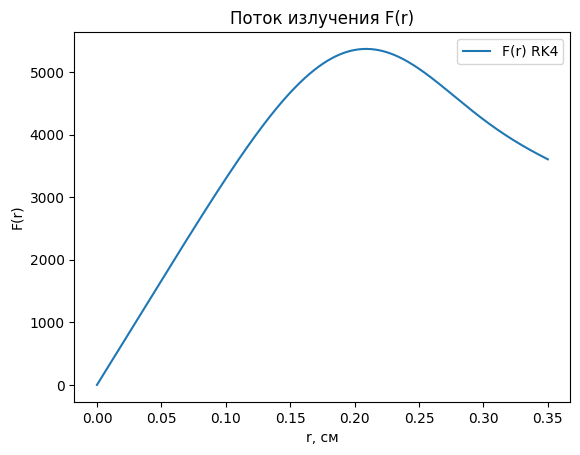

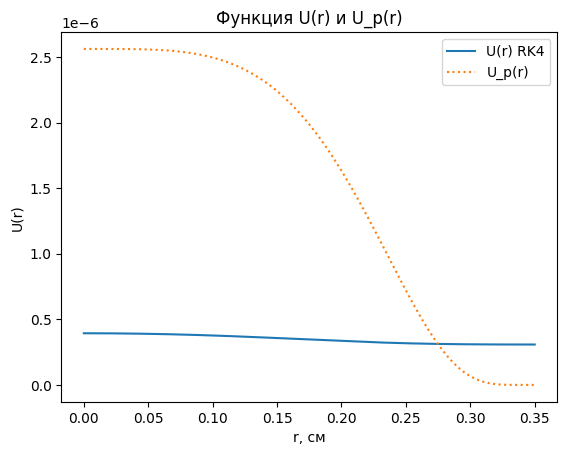

In [3]:
phi_min = 0.0
phi_max = 1.0

phi_solution_rk4 = find_phi(phi_min, phi_max, method='rk4', tol=1e-8)
print("Найдено phi (RK4) =", phi_solution_rk4)

r_vals, U_vals, F_vals = solve_ivp_shooting(phi_solution_rk4, method='rk4')

# phi_solution_rk2 = find_phi(phi_min, phi_max, method='rk2', tol=1e-8)
# print("Найдено phi (RK2) =", phi_solution_rk2)
# r_vals2, U_vals2, F_vals2 = solve_ivp_shooting(phi_solution_rk2, method='rk2')

Up_vals = [U_p_of_r(rr) for rr in r_vals]

plt.figure()
plt.plot(r_vals, F_vals, label="F(r) RK4")
# plt.plot(r_vals2, F_vals2, '--', label="F(r) RK2")
plt.xlabel("r, см")
plt.ylabel("F(r)")
plt.title("Поток излучения F(r)")
plt.legend()
plt.show()

plt.figure()
plt.plot(r_vals, U_vals, label="U(r) RK4")
# plt.plot(r_vals2, U_vals2, '--', label="U(r) RK2")
plt.plot(r_vals, Up_vals, ':', label="U_p(r)")
plt.xlabel("r, см")
plt.ylabel("U(r)")
plt.title("Функция U(r) и U_p(r)")
plt.legend()
plt.show()